# Deprivation and Life Expectancy Across English Local Authorities

## Project Overview

### Research question

**Is higher deprivation associated with lower life expectancy across English local authorities?**

### Objective

This project investigates the relationship between deprivation and life expectancy across English local authorities using publicly available government data.

The analysis combines:

- **ONS life expectancy estimates for 2022–2024**
- **English Indices of Deprivation 2025**
- **SQL** for data integration
- **Python** for data cleaning, statistical analysis and visualisation

The project uses correlation analysis, linear regression, group comparisons, ANOVA, residual analysis and sex-specific sensitivity analysis to investigate the relationship.

### Key findings

- **292** English local authorities were included after matching the two datasets.
- Pearson correlation between deprivation and life expectancy: **r = −0.861**
- Linear regression **R² = 0.741**
- A 10-point increase in deprivation score corresponded to approximately **1.74 fewer predicted years** of life expectancy.
- Mean life expectancy differed by approximately **3.05 years** between the Low and High deprivation groups.
- The negative association was observed for both males and females.
- Residual analysis showed that deprivation alone did not explain all local variation in life expectancy.

> **Important:** This is an ecological observational analysis. The findings demonstrate an association between deprivation and life expectancy at local-authority level and should not be interpreted as evidence of individual-level causation.

## Tools & Technologies

**Languages:** Python, SQL

**Python libraries:** pandas, NumPy, SciPy, statsmodels, Matplotlib

**SQL:** DuckDB

**Environment:** Google Colab

**Data sources:** Office for National Statistics (ONS), English Indices of Deprivation 2025

## 1. Import Libraries and Load ONS Data

In [1]:
# Install DuckDB
!pip install duckdb

# Import libraries
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file = "sample_data/lifeexpectancylocalareas.xlsx"

raw = pd.read_excel(
    file,
    sheet_name="1",
    header=None
)

headers = raw.iloc[5].tolist()

life_expectancy = raw.iloc[6:].copy()

life_expectancy.columns = headers

life_expectancy = life_expectancy.reset_index(drop=True)

print(life_expectancy.columns.tolist())

life_expectancy.head()

['Period', 'Country', 'Area type', 'Area code', 'Area name', 'Sex', 'Sex code', 'Age group', 'Age code', 'Life expectancy', 'Lower confidence interval', 'Upper confidence interval']


,Period,Country,Area type,Area code,Area name,Sex,Sex code,Age group,Age code,Life expectancy,Lower confidence interval,Upper confidence interval
0,2001 to 2003,England,Local Areas,E06000001,Hartlepool,Male,1,<1,1,73.4,72.7,74.2
1,2001 to 2003,England,Local Areas,E06000001,Hartlepool,Male,1,01 to 04,2,72.9,72.2,73.6
2,2001 to 2003,England,Local Areas,E06000001,Hartlepool,Male,1,05 to 09,3,68.9,68.3,69.6
3,2001 to 2003,England,Local Areas,E06000001,Hartlepool,Male,1,10 to 14,4,64,63.3,64.6
4,2001 to 2003,England,Local Areas,E06000001,Hartlepool,Male,1,15 to 19,5,59,58.3,59.7


## 2. Filter and Prepare Life Expectancy Data

In [2]:
life_expectancy_2022 = life_expectancy[
    (life_expectancy["Period"] == "2022 to 2024") &
    (life_expectancy["Country"] == "England") &
    (life_expectancy["Area type"] == "Local Areas") &
    (life_expectancy["Age group"] == "<1")
].copy()

life_expectancy_2022.head()

,Period,Country,Area type,Area code,Area name,Sex,Sex code,Age group,Age code,Life expectancy,Lower confidence interval,Upper confidence interval
379680,2022 to 2024,England,Local Areas,E06000001,Hartlepool,Male,1,<1,1,77.3,76.5,78
379700,2022 to 2024,England,Local Areas,E06000001,Hartlepool,Female,2,<1,1,80.3,79.6,81
379720,2022 to 2024,England,Local Areas,E06000002,Middlesbrough,Male,1,<1,1,75.5,74.9,76.1
379740,2022 to 2024,England,Local Areas,E06000002,Middlesbrough,Female,2,<1,1,80.5,79.9,81
379760,2022 to 2024,England,Local Areas,E06000003,Redcar and Cleveland,Male,1,<1,1,77,76.3,77.6


In [3]:
print("Number of rows:", len(life_expectancy_2022))
life_expectancy_2022["Sex"].value_counts()

Number of rows: 630


,count
Sex,
Male,315
Female,315


In [4]:
life_expectancy_2022 = life_expectancy_2022[
    [
        "Area code",
        "Area name",
        "Sex",
        "Life expectancy"
    ]
].copy()

life_expectancy_2022.head(10)

,Area code,Area name,Sex,Life expectancy
379680,E06000001,Hartlepool,Male,77.3
379700,E06000001,Hartlepool,Female,80.3
379720,E06000002,Middlesbrough,Male,75.5
379740,E06000002,Middlesbrough,Female,80.5
379760,E06000003,Redcar and Cleveland,Male,77
379780,E06000003,Redcar and Cleveland,Female,81.5
379800,E06000004,Stockton-on-Tees,Male,78.7
379820,E06000004,Stockton-on-Tees,Female,81.8
379840,E06000005,Darlington,Male,77.7
379860,E06000005,Darlington,Female,81.5


In [5]:
life_expectancy_avg = (
    life_expectancy_2022
    .groupby(["Area code", "Area name"], as_index=False)
    ["Life expectancy"]
    .mean()
)

life_expectancy_avg = life_expectancy_avg.rename(
    columns={"Life expectancy": "Average life expectancy"}
)

life_expectancy_avg.head(10)

,Area code,Area name,Average life expectancy
0,E06000001,Hartlepool,78.8
1,E06000002,Middlesbrough,78.0
2,E06000003,Redcar and Cleveland,79.25
3,E06000004,Stockton-on-Tees,80.25
4,E06000005,Darlington,79.6
5,E06000006,Halton,79.05
6,E06000007,Warrington,80.4
7,E06000008,Blackburn with Darwen,78.45
8,E06000009,Blackpool,76.4
9,E06000010,"Kingston upon Hull, City of",77.95


In [6]:
print("Number of local authorities:", len(life_expectancy_avg))

Number of local authorities: 315


## 3. Load and Prepare Deprivation Data

In [7]:
deprivation_file = "sample_data/deprivation.xlsx"

deprivation = pd.read_excel(
    deprivation_file,
    sheet_name="IMD",
    header=0
)

print(deprivation.columns.tolist())

['Local Authority District code (2024)', 'Local Authority District name (2024)', 'IMD - Average rank ', 'IMD - Rank of average rank ', 'IMD - Average score ', 'IMD - Rank of average score ', 'IMD - Proportion of LSOAs in most deprived 10% nationally ', 'IMD - Rank of proportion of LSOAs in most deprived 10% nationally ', 'IMD25 - Extent ', 'IMD25 - Rank of extent ', 'IMD25 - Local concentration ', 'IMD25 - Rank of local concentration ']


In [8]:
deprivation = deprivation[
    [
        "Local Authority District code (2024)",
        "Local Authority District name (2024)",
        "IMD - Average score "
    ]
].copy()

In [9]:
deprivation = deprivation.rename(
    columns={
        "Local Authority District code (2024)": "Area code",
        "Local Authority District name (2024)": "Area name",
        "IMD - Average score ": "Deprivation score"
    }
)

deprivation.head(10)

,Area code,Area name,Deprivation score
0,E06000001,Hartlepool,37.580
1,E06000002,Middlesbrough,40.037
2,E06000003,Redcar and Cleveland,30.336
3,E06000004,Stockton-on-Tees,25.830
4,E06000005,Darlington,25.713
5,E06000006,Halton,31.117
6,E06000007,Warrington,16.835
7,E06000008,Blackburn with Darwen,36.899
8,E06000009,Blackpool,43.467
9,E06000010,"Kingston upon Hull, City of",37.206


In [10]:
print("Number of deprivation records:", len(deprivation))
print("Unique local authorities:", deprivation["Area code"].nunique())

Number of deprivation records: 296
Unique local authorities: 296


## 4. Combine Datasets Using SQL

In [11]:

con = duckdb.connect()

con.register("life_expectancy", life_expectancy_avg)
con.register("deprivation", deprivation)

combined = con.execute("""
    SELECT
        l."Area code",
        l."Area name",
        l."Average life expectancy",
        d."Deprivation score"
    FROM life_expectancy AS l
    INNER JOIN deprivation AS d
        ON l."Area code" = d."Area code"
""").df()

combined.head(10)

,Area code,Area name,Average life expectancy,Deprivation score
0,E06000001,Hartlepool,78.80,37.580
1,E06000002,Middlesbrough,78.00,40.037
2,E06000003,Redcar and Cleveland,79.25,30.336
3,E06000004,Stockton-on-Tees,80.25,25.830
4,E06000005,Darlington,79.60,25.713
5,E06000006,Halton,79.05,31.117
6,E06000007,Warrington,80.40,16.835
7,E06000008,Blackburn with Darwen,78.45,36.899
8,E06000009,Blackpool,76.40,43.467
9,E06000010,"Kingston upon Hull, City of",77.95,37.206


In [12]:
print("Combined rows:", len(combined))
print("Missing deprivation scores:", combined["Deprivation score"].isna().sum())

Combined rows: 292
Missing deprivation scores: 0


## 5. Check Geographic Matching

In [13]:
unmatched_life = con.execute("""
    SELECT
        l."Area code",
        l."Area name"
    FROM life_expectancy AS l
    LEFT JOIN deprivation AS d
        ON l."Area code" = d."Area code"
    WHERE d."Area code" IS NULL
""").df()

unmatched_life

,Area code,Area name
0,E08000038,Barnsley
1,E08000039,Sheffield
2,E10000003,Cambridgeshire
3,E10000007,Derbyshire
4,E10000008,Devon
5,E10000011,East Sussex
6,E10000012,Essex
7,E10000013,Gloucestershire
8,E10000014,Hampshire
9,E10000015,Hertfordshire


In [14]:
print("Unmatched life expectancy authorities:", len(unmatched_life))

Unmatched life expectancy authorities: 23


The ONS dataset contained 315 English local-area records after filtering. Twenty-three records could not be matched to the Local Authority District-level deprivation dataset and were therefore excluded from the final analysis. The final dataset contained 292 matched local authorities.

## 6. Data Quality Checks

In [15]:
analysis_data = combined.copy()

print("Final analysis records:", len(analysis_data))
analysis_data.head(10)

Final analysis records: 292


,Area code,Area name,Average life expectancy,Deprivation score
0,E06000001,Hartlepool,78.80,37.580
1,E06000002,Middlesbrough,78.00,40.037
2,E06000003,Redcar and Cleveland,79.25,30.336
3,E06000004,Stockton-on-Tees,80.25,25.830
4,E06000005,Darlington,79.60,25.713
5,E06000006,Halton,79.05,31.117
6,E06000007,Warrington,80.40,16.835
7,E06000008,Blackburn with Darwen,78.45,36.899
8,E06000009,Blackpool,76.40,43.467
9,E06000010,"Kingston upon Hull, City of",77.95,37.206


In [16]:
analysis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area code                292 non-null    object 
 1   Area name                292 non-null    object 
 2   Average life expectancy  292 non-null    float64
 3   Deprivation score        292 non-null    float64
dtypes: float64(2), object(2)
memory usage: 9.3+ KB


In [17]:
print("Missing values:")
print(analysis_data.isna().sum())

print("\nDuplicate rows:", analysis_data.duplicated().sum())

print("\nData types:")
print(analysis_data.dtypes)

Missing values:
Area code                  0
Area name                  0
Average life expectancy    0
Deprivation score          0
dtype: int64

Duplicate rows: 0

Data types:
Area code                   object
Area name                   object
Average life expectancy    float64
Deprivation score          float64
dtype: object


In [18]:
print("Duplicate area codes:", analysis_data["Area code"].duplicated().sum())
print("Duplicate area names:", analysis_data["Area name"].duplicated().sum())

Duplicate area codes: 0
Duplicate area names: 0


## 7. Exploratory Analysis

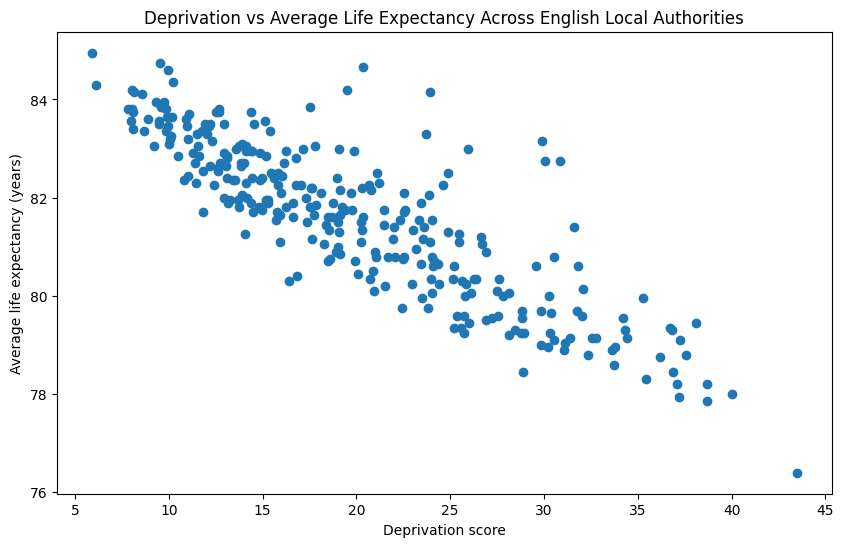

In [19]:

plt.figure(figsize=(10, 6))

plt.scatter(
    analysis_data["Deprivation score"],
    analysis_data["Average life expectancy"]
)

plt.xlabel("Deprivation score")
plt.ylabel("Average life expectancy (years)")
plt.title("Deprivation vs Average Life Expectancy Across English Local Authorities")

plt.show()

## 8. Correlation and Linear Regression

In [20]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation
pearson_r, pearson_p = pearsonr(
    analysis_data["Deprivation score"],
    analysis_data["Average life expectancy"]
)

# Spearman correlation
spearman_r, spearman_p = spearmanr(
    analysis_data["Deprivation score"],
    analysis_data["Average life expectancy"]
)

print(f"Pearson correlation: {pearson_r:.3f}")
print(f"Pearson p-value: {pearson_p:.4g}")

print(f"Spearman correlation: {spearman_r:.3f}")
print(f"Spearman p-value: {spearman_p:.4g}")

Pearson correlation: -0.861
Pearson p-value: 4.312e-87
Spearman correlation: -0.847
Spearman p-value: 1.326e-81


In [21]:
from scipy.stats import linregress

regression = linregress(
    analysis_data["Deprivation score"],
    analysis_data["Average life expectancy"]
)

print(f"Slope: {regression.slope:.3f}")
print(f"Intercept: {regression.intercept:.3f}")
print(f"R-squared: {regression.rvalue**2:.3f}")
print(f"p-value: {regression.pvalue:.4g}")
print(f"Standard error: {regression.stderr:.3f}")

Slope: -0.174
Intercept: 85.081
R-squared: 0.741
p-value: 4.312e-87
Standard error: 0.006


## 9. Regression Visualisation

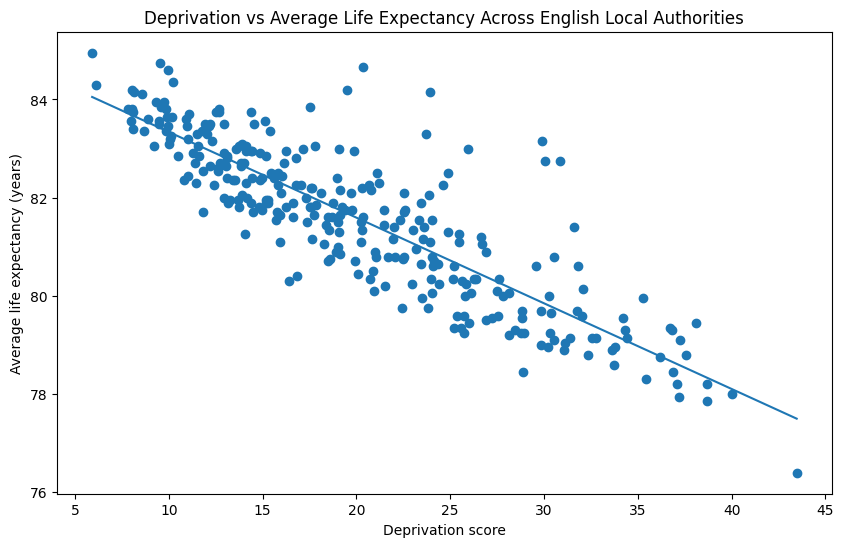

In [22]:

x = analysis_data["Deprivation score"]
y = analysis_data["Average life expectancy"]

x_sorted = np.sort(x)

y_pred = regression.intercept + regression.slope * x_sorted

plt.figure(figsize=(10, 6))

plt.scatter(x, y)
plt.plot(x_sorted, y_pred)

plt.xlabel("Deprivation score")
plt.ylabel("Average life expectancy (years)")
plt.title("Deprivation vs Average Life Expectancy Across English Local Authorities")

plt.show()

## 10. Residual Analysis

In [23]:
analysis_data["Predicted life expectancy"] = (
    regression.intercept
    + regression.slope * analysis_data["Deprivation score"]
)

analysis_data["Residual"] = (
    analysis_data["Average life expectancy"]
    - analysis_data["Predicted life expectancy"]
)

analysis_data.head()

,Area code,Area name,Average life expectancy,Deprivation score,Predicted life expectancy,Residual
0,E06000001,Hartlepool,78.80,37.580,78.527127,0.272873
1,E06000002,Middlesbrough,78.00,40.037,78.098641,-0.098641
2,E06000003,Redcar and Cleveland,79.25,30.336,79.790438,-0.540438
3,E06000004,Stockton-on-Tees,80.25,25.830,80.576258,-0.326258
4,E06000005,Darlington,79.60,25.713,80.596662,-0.996662


In [24]:
analysis_data.sort_values(
    "Residual",
    ascending=False
).head(10)

,Area code,Area name,Average life expectancy,Deprivation score,Predicted life expectancy,Residual
268,E09000010,Enfield,83.15,29.888,79.868566,3.281434
291,E09000033,Westminster,84.15,23.931,80.907432,3.242568
278,E09000020,Kensington and Chelsea,84.65,20.339,81.533856,3.116144
272,E09000014,Haringey,82.75,30.856,79.699753,3.050247
263,E09000005,Brent,82.75,30.046,79.841012,2.908988
261,E09000003,Barnet,84.20,19.499,81.680347,2.519653
267,E09000009,Ealing,83.00,25.947,80.555853,2.444147
265,E09000007,Camden,83.30,23.695,80.948589,2.351411
283,E09000025,Newham,81.40,31.583,79.572968,1.827032
273,E09000015,Harrow,83.85,17.527,82.024252,1.825748


In [25]:
analysis_data.sort_values(
    "Residual",
    ascending=True
).head(10)

,Area code,Area name,Average life expectancy,Deprivation score,Predicted life expectancy,Residual
136,E07000118,Chorley,80.30,16.381,82.224107,-1.924107
6,E06000007,Warrington,80.40,16.835,82.144932,-1.744932
156,E07000138,Lincoln,78.45,28.872,80.045751,-1.595751
139,E07000121,Lancaster,79.75,22.408,81.173034,-1.423034
204,E07000220,Rugby,81.25,14.059,82.629050,-1.379050
68,E07000033,Bolsover,79.25,25.728,80.594046,-1.344046
235,E08000010,Wigan,79.35,25.206,80.685079,-1.335079
244,E08000022,North Tyneside,80.10,20.932,81.430440,-1.330440
13,E06000014,York,81.70,11.814,83.020565,-1.320565
168,E07000170,Ashfield,79.35,25.568,80.621949,-1.271949


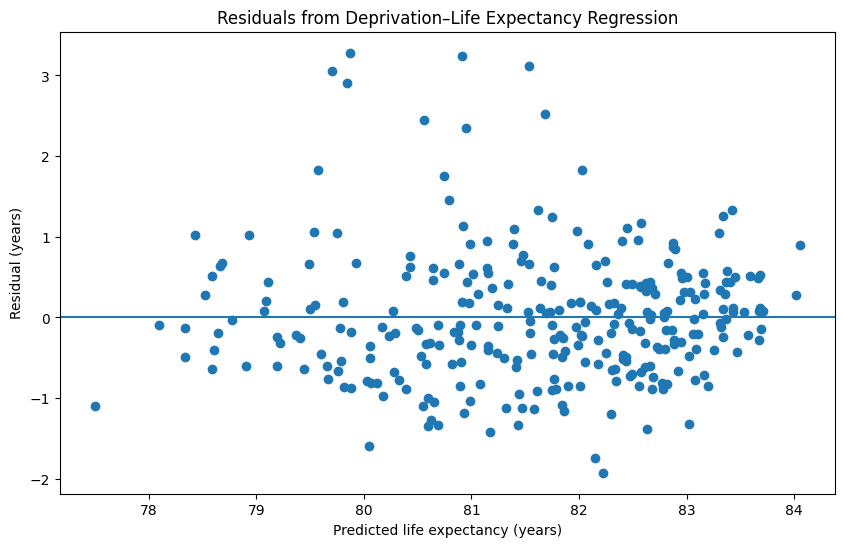

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(
    analysis_data["Predicted life expectancy"],
    analysis_data["Residual"]
)

plt.axhline(0)

plt.xlabel("Predicted life expectancy (years)")
plt.ylabel("Residual (years)")
plt.title("Residuals from Deprivation–Life Expectancy Regression")

plt.show()

## 11. Deprivation Group Analysis

In [27]:
analysis_data["Deprivation group"] = pd.qcut(
    analysis_data["Deprivation score"],
    q=3,
    labels=["Low deprivation", "Medium deprivation", "High deprivation"]
)

analysis_data["Deprivation group"].value_counts()

,count
Deprivation group,
Low deprivation,98
Medium deprivation,97
High deprivation,97


In [28]:
group_summary = (
    analysis_data
    .groupby("Deprivation group", observed=True)["Average life expectancy"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

group_summary

,Deprivation group,count,mean,median,std
0,Low deprivation,98,83.041837,83.05,0.755655
1,Medium deprivation,97,81.691753,81.70,0.873203
2,High deprivation,97,79.988660,79.70,1.308715


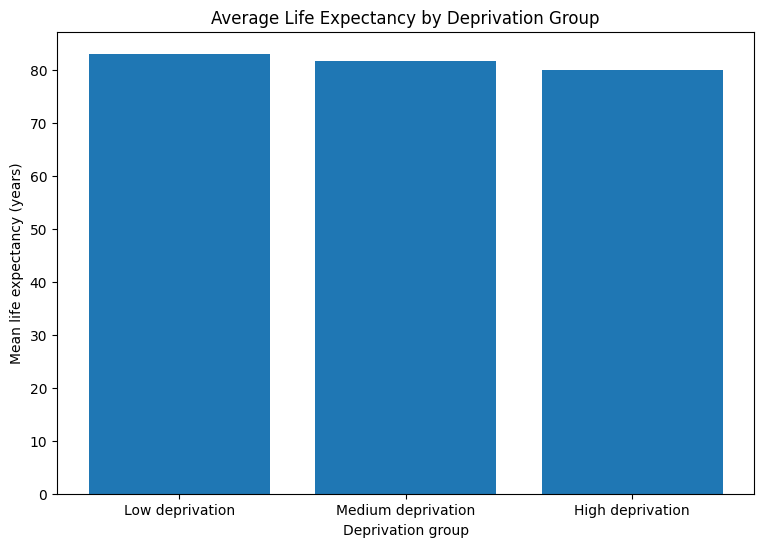

In [29]:

plt.figure(figsize=(9, 6))

plt.bar(
    group_summary["Deprivation group"],
    group_summary["mean"]
)

plt.xlabel("Deprivation group")
plt.ylabel("Mean life expectancy (years)")
plt.title("Average Life Expectancy by Deprivation Group")

plt.show()

## 12. ANOVA and Tukey HSD

In [30]:
from scipy.stats import f_oneway

low = analysis_data[
    analysis_data["Deprivation group"] == "Low deprivation"
]["Average life expectancy"]

medium = analysis_data[
    analysis_data["Deprivation group"] == "Medium deprivation"
]["Average life expectancy"]

high = analysis_data[
    analysis_data["Deprivation group"] == "High deprivation"
]["Average life expectancy"]

anova_result = f_oneway(low, medium, high)

print(f"F-statistic: {anova_result.statistic:.3f}")
print(f"p-value: {anova_result.pvalue:.4g}")

F-statistic: 225.015
p-value: 1.197e-59


In [31]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=analysis_data["Average life expectancy"],
    groups=analysis_data["Deprivation group"],
    alpha=0.05
)

print(tukey)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1            group2       meandiff p-adj  lower   upper  reject
-------------------------------------------------------------------------
High deprivation    Low deprivation   3.0532   0.0  2.7134  3.3929   True
High deprivation Medium deprivation   1.7031   0.0  1.3625  2.0437   True
 Low deprivation Medium deprivation  -1.3501   0.0 -1.6898 -1.0103   True
-------------------------------------------------------------------------


## 13. Sex-Specific Sensitivity Analysis

In [32]:
for sex in ["Male", "Female"]:

    sex_data = life_expectancy_2022[
        life_expectancy_2022["Sex"] == sex
    ].copy()

    sex_data = sex_data[
        ["Area code", "Area name", "Life expectancy"]
    ]

    sex_data = sex_data.rename(
        columns={"Life expectancy": "Life expectancy"}
    )

    sex_combined = con.execute("""
        SELECT
            l."Area code",
            l."Area name",
            l."Life expectancy",
            d."Deprivation score"
        FROM sex_data AS l
        INNER JOIN deprivation AS d
            ON l."Area code" = d."Area code"
    """).df()

    correlation = sex_combined[
        ["Deprivation score", "Life expectancy"]
    ].corr().iloc[0, 1]

    print(f"{sex}: Pearson correlation = {correlation:.3f}")

Male: Pearson correlation = -0.885
Female: Pearson correlation = -0.806


In [33]:
from scipy.stats import linregress

for sex in ["Male", "Female"]:

    sex_data = life_expectancy_2022[
        life_expectancy_2022["Sex"] == sex
    ][["Area code", "Area name", "Life expectancy"]].copy()


    sex_combined = con.execute("""
        SELECT
            l."Area code",
            l."Area name",
            l."Life expectancy",
            d."Deprivation score"
        FROM sex_data AS l
        INNER JOIN deprivation AS d
            ON l."Area code" = d."Area code"
    """).df()

    regression = linregress(
        sex_combined["Deprivation score"],
        sex_combined["Life expectancy"]
    )

    print(f"\n{sex}")
    print(f"Slope: {regression.slope:.3f}")
    print(f"Intercept: {regression.intercept:.3f}")
    print(f"R-squared: {regression.rvalue**2:.3f}")
    print(f"p-value: {regression.pvalue:.4g}")
    print(f"Standard error: {regression.stderr:.3f}")


Male
Slope: -0.194
Intercept: 83.552
R-squared: 0.783
p-value: 2.456e-98
Standard error: 0.006

Female
Slope: -0.155
Intercept: 86.610
R-squared: 0.650
p-value: 4.21e-68
Standard error: 0.007


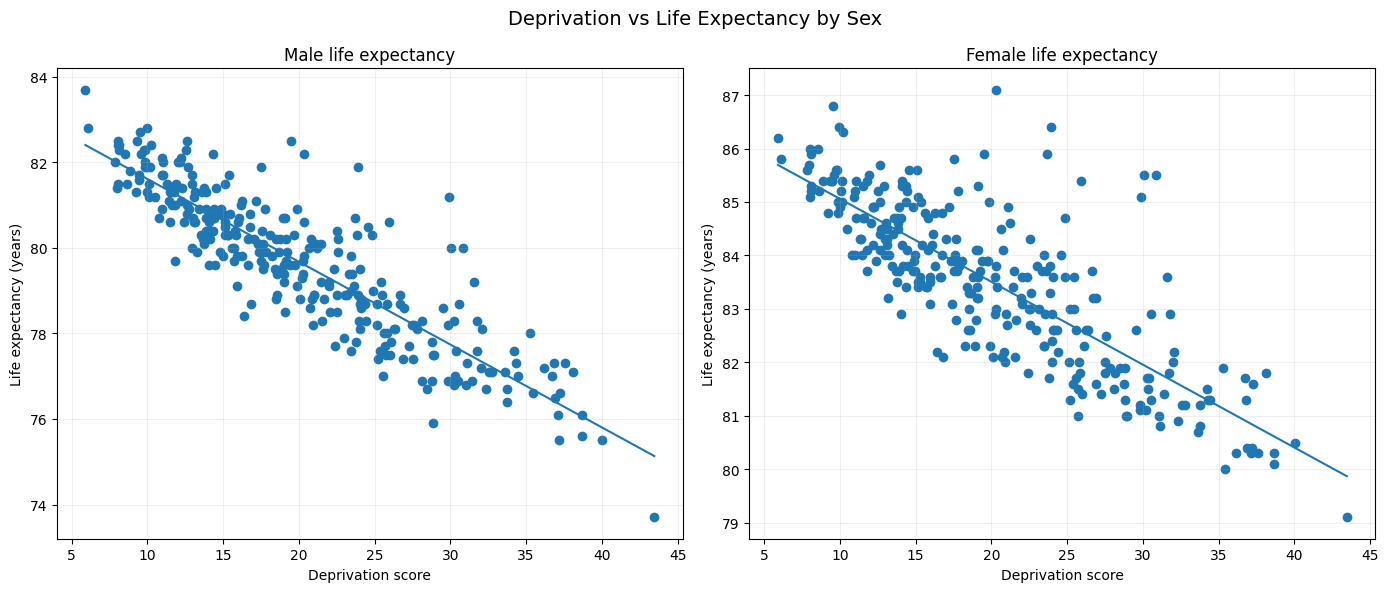

In [34]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sex in zip(axes, ["Male", "Female"]):

    sex_data = life_expectancy_2022[
        life_expectancy_2022["Sex"] == sex
    ][["Area code", "Area name", "Life expectancy"]].copy()

    sex_combined = con.execute("""
        SELECT
            l."Area code",
            l."Area name",
            l."Life expectancy",
            d."Deprivation score"
        FROM sex_data AS l
        INNER JOIN deprivation AS d
            ON l."Area code" = d."Area code"
    """).df()

    regression = linregress(
        sex_combined["Deprivation score"],
        sex_combined["Life expectancy"]
    )

    x = np.sort(sex_combined["Deprivation score"])
    y_pred = regression.intercept + regression.slope * x

    ax.scatter(
        sex_combined["Deprivation score"],
        sex_combined["Life expectancy"]
    )

    ax.plot(x, y_pred)

    ax.set_xlabel("Deprivation score")
    ax.set_ylabel("Life expectancy (years)")
    ax.set_title(f"{sex} life expectancy")
    ax.grid(alpha=0.2)

plt.suptitle(
    "Deprivation vs Life Expectancy by Sex",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 14. Final Visualisations

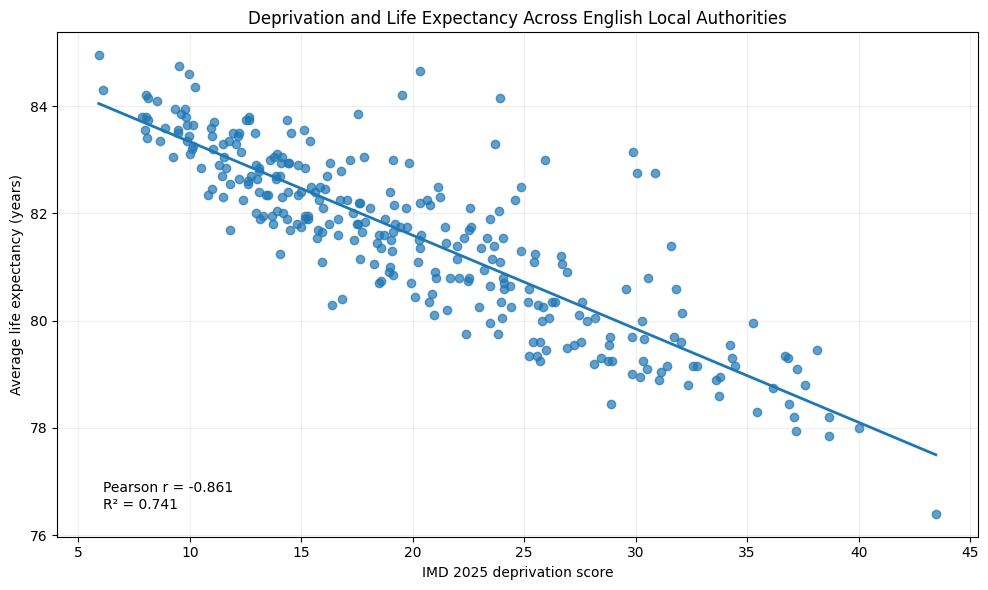

In [35]:

x = analysis_data["Deprivation score"]
y = analysis_data["Average life expectancy"]

regression = linregress(x, y)

x_sorted = np.sort(x)
y_pred = regression.intercept + regression.slope * x_sorted

plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.7)
plt.plot(
    x_sorted,
    y_pred,
    linewidth=2
)

plt.xlabel("IMD 2025 deprivation score")
plt.ylabel("Average life expectancy (years)")
plt.title(
    "Deprivation and Life Expectancy Across English Local Authorities"
)

plt.text(
    0.05,
    0.05,
    f"Pearson r = {regression.rvalue:.3f}\n"
    f"R² = {regression.rvalue**2:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="bottom"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "deprivation_vs_life_expectancy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

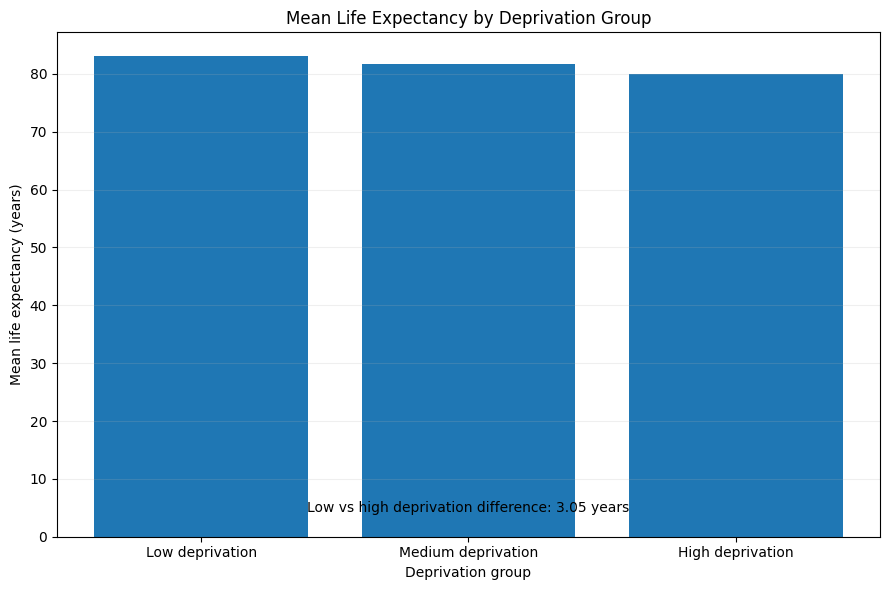

In [36]:

group_summary = (
    analysis_data
    .groupby("Deprivation group", observed=True)["Average life expectancy"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 6))

plt.bar(
    group_summary["Deprivation group"],
    group_summary["Average life expectancy"]
)

plt.xlabel("Deprivation group")
plt.ylabel("Mean life expectancy (years)")
plt.title(
    "Mean Life Expectancy by Deprivation Group"
)

plt.text(
    0.5,
    0.05,
    "Low vs high deprivation difference: 3.05 years",
    transform=plt.gca().transAxes,
    ha="center"
)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(
    "life_expectancy_by_deprivation_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

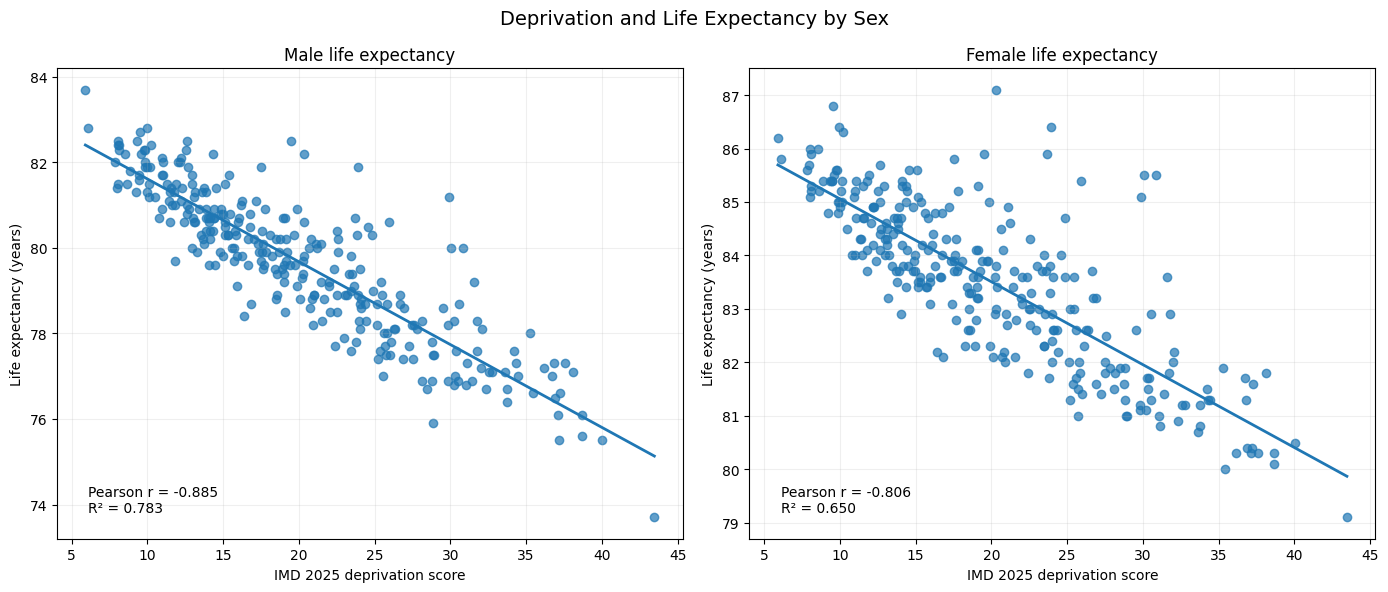

In [37]:

from scipy.stats import linregress

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sex in zip(axes, ["Male", "Female"]):

    sex_data = life_expectancy_2022[
        life_expectancy_2022["Sex"] == sex
    ][["Area code", "Area name", "Life expectancy"]].copy()

    sex_combined = con.execute("""
        SELECT
            l."Area code",
            l."Area name",
            l."Life expectancy",
            d."Deprivation score"
        FROM sex_data AS l
        INNER JOIN deprivation AS d
            ON l."Area code" = d."Area code"
    """).df()

    regression = linregress(
        sex_combined["Deprivation score"],
        sex_combined["Life expectancy"]
    )

    x = sex_combined["Deprivation score"]
    y = sex_combined["Life expectancy"]

    x_sorted = np.sort(x)
    y_pred = (
        regression.intercept
        + regression.slope * x_sorted
    )

    ax.scatter(x, y, alpha=0.7)
    ax.plot(x_sorted, y_pred, linewidth=2)

    ax.set_xlabel("IMD 2025 deprivation score")
    ax.set_ylabel("Life expectancy (years)")
    ax.set_title(f"{sex} life expectancy")

    ax.text(
        0.05,
        0.05,
        f"Pearson r = {regression.rvalue:.3f}\n"
        f"R² = {regression.rvalue**2:.3f}",
        transform=ax.transAxes,
        verticalalignment="bottom"
    )

    ax.grid(alpha=0.2)

fig.suptitle(
    "Deprivation and Life Expectancy by Sex",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "deprivation_life_expectancy_by_sex.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

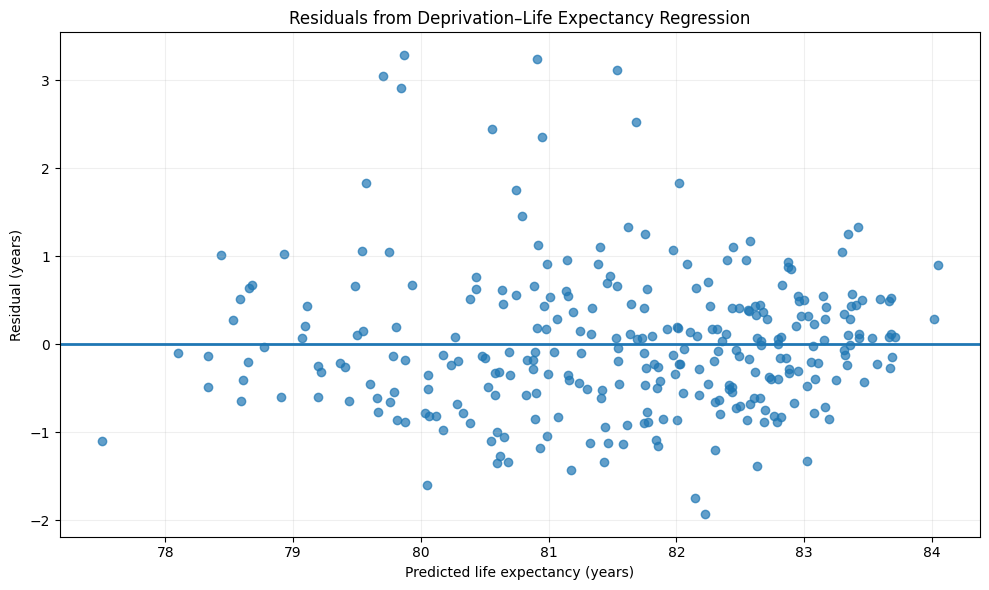

In [38]:

plt.figure(figsize=(10, 6))

plt.scatter(
    analysis_data["Predicted life expectancy"],
    analysis_data["Residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linewidth=2
)

plt.xlabel("Predicted life expectancy (years)")
plt.ylabel("Residual (years)")
plt.title(
    "Residuals from Deprivation–Life Expectancy Regression"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "deprivation_life_expectancy_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Save Analysis Outputs

In [39]:
analysis_data.to_csv(
    "deprivation_life_expectancy_analysis.csv",
    index=False
)

In [40]:
results_summary = pd.DataFrame({
    "Analysis": [
        "Overall Pearson correlation",
        "Overall Spearman correlation",
        "Overall regression R²",
        "Overall regression slope",
        "Low vs high deprivation difference",
        "ANOVA F-statistic",
        "Male Pearson correlation",
        "Male regression R²",
        "Male regression slope",
        "Female Pearson correlation",
        "Female regression R²",
        "Female regression slope"
    ],
    "Result": [
        -0.861,
        -0.847,
        0.741,
        -0.174,
        3.053,
        225.015,
        -0.885,
        0.783,
        -0.194,
        -0.806,
        0.650,
        -0.155
    ]
})

results_summary

,Analysis,Result
0,Overall Pearson correlation,-0.861
1,Overall Spearman correlation,-0.847
2,Overall regression R²,0.741
3,Overall regression slope,-0.174
4,Low vs high deprivation difference,3.053
5,ANOVA F-statistic,225.015
6,Male Pearson correlation,-0.885
7,Male regression R²,0.783
8,Male regression slope,-0.194
9,Female Pearson correlation,-0.806


In [41]:
results_summary_clean = results_summary.copy()

results_summary_clean["Result"] = (
    results_summary_clean["Result"].round(3)
)

results_summary_clean.to_csv(
    "project_results_summary.csv",
    index=False
)

results_summary_clean

,Analysis,Result
0,Overall Pearson correlation,-0.861
1,Overall Spearman correlation,-0.847
2,Overall regression R²,0.741
3,Overall regression slope,-0.174
4,Low vs high deprivation difference,3.053
5,ANOVA F-statistic,225.015
6,Male Pearson correlation,-0.885
7,Male regression R²,0.783
8,Male regression slope,-0.194
9,Female Pearson correlation,-0.806


## Methodology

### Data sources

Two publicly available datasets were used:

- **Office for National Statistics (ONS):** Life expectancy for local areas of the UK, using 2022–2024 estimates for English local areas.
- **English Indices of Deprivation (IoD) 2025:** Local Authority District-level deprivation data, using the IMD Average Score as the measure of deprivation.

### Data preparation

The ONS dataset was filtered to:

- England
- Local Areas
- 2022–2024
- Age group <1

Male and female life expectancy estimates were then averaged to calculate an overall average life expectancy for each local authority.

The deprivation dataset was filtered to retain the 2024 Local Authority District code, Local Authority District name and IMD 2025 Average Score.

The two datasets were joined using the local authority geographical code. This produced a final dataset of **292 matched English local authorities**.

### Exploratory analysis

The relationship between deprivation and life expectancy was investigated using:

- Scatter plots
- Pearson correlation
- Spearman correlation
- Simple linear regression
- R²
- Residual analysis

Local authorities were also divided into three groups based on their deprivation score:

- Low deprivation
- Medium deprivation
- High deprivation

Mean life expectancy was compared across these groups using one-way ANOVA followed by Tukey's HSD post-hoc testing.

### Sensitivity analysis

The deprivation–life expectancy relationship was analysed separately for males and females to assess whether the overall finding was consistent across sexes.

### SQL analysis

SQL was used with DuckDB to join the life expectancy and deprivation datasets using the local authority geographical code.

### Interpretation

The analysis assesses associations between deprivation and life expectancy at local-authority level. It does not establish that deprivation directly causes differences in life expectancy.

Because this is an ecological analysis, findings at local-authority level cannot be assumed to apply directly to individuals.

## Limitations

Several limitations should be considered when interpreting the findings.

### Ecological analysis

The analysis was conducted at local-authority level. Therefore, relationships observed between deprivation and life expectancy across areas cannot be assumed to apply directly to individuals within those areas. This is an ecological analysis and does not establish individual-level relationships.

### Association does not imply causation

The strong negative relationship between deprivation and life expectancy indicates an association, but does not demonstrate that deprivation itself causes lower life expectancy. Other factors may contribute to differences between local authorities, including demographics, health behaviours, access to healthcare and other socioeconomic characteristics.

### Difference in time periods

Life expectancy estimates cover **2022–2024**, while the deprivation measure is from the **2025 English Indices of Deprivation**. Although the periods are relatively close, they are not identical, so the deprivation measure should not be interpreted as representing the exact conditions during the entire life expectancy period.

### Geographic matching

The ONS dataset contained 315 English local-area records after filtering, while the deprivation dataset contained 296 Local Authority Districts. After matching by geographic code, 292 local authorities were retained. Some ONS records represented larger county or upper-tier geographies that were not directly represented in the Local Authority District deprivation dataset and were therefore excluded.

### Deprivation group definitions

The Low, Medium and High deprivation groups were created using tertiles of the deprivation score. These are analytical categories created for this project rather than official government deprivation classifications.

### Statistical significance

The large sample size and strong association produced very small p-values. Therefore, effect sizes such as the correlation coefficient, regression slope, R² and difference in mean life expectancy provide more useful information about the magnitude of the relationship than statistical significance alone.

### Model limitations

The analysis used simple linear regression with deprivation as the only explanatory variable. Although residuals were broadly scattered around zero, the model does not account for other variables that may explain variation in life expectancy between local authorities.

## Results & Findings

### Overall relationship

There was a strong negative association between deprivation and average life expectancy across the 292 English local authorities included in the analysis.

- **Pearson correlation:** r = −0.861
- **Spearman correlation:** ρ = −0.847
- **R²:** 0.741
- **Regression slope:** −0.174 years per 1-point increase in deprivation score

The linear regression model estimated that a 10-point increase in deprivation score was associated with approximately **1.74 fewer years of predicted life expectancy**.

The similarity between the Pearson and Spearman correlations indicates that the strong negative relationship was not substantially altered when the analysis was based on rank rather than the raw values.

### Deprivation groups

Local authorities were divided into Low, Medium and High deprivation groups using tertiles of the deprivation score.

| Deprivation group | Number of local authorities | Mean life expectancy |
|---|---:|---:|
| Low | 98 | 83.04 years |
| Medium | 97 | 81.69 years |
| High | 97 | 79.99 years |

The difference in mean life expectancy between the Low and High deprivation groups was approximately **3.05 years**.

A one-way ANOVA found evidence of differences in mean life expectancy between the three groups (F = 225.015, p < 0.001). Tukey's HSD post-hoc analysis indicated that all three pairwise group comparisons differed statistically significantly.

### Sex-specific analysis

The negative association between deprivation and life expectancy was also observed when analysing males and females separately.

| Sex | Pearson correlation | R² | Regression slope |
|---|---:|---:|---:|
| Male | −0.885 | 0.783 | −0.194 |
| Female | −0.806 | 0.650 | −0.155 |

For males, the regression estimated approximately **1.94 fewer years of predicted life expectancy per 10-point increase in deprivation score**.

For females, the corresponding estimate was approximately **1.55 fewer years**.

The relationship therefore remained negative for both sexes, providing a sensitivity check that the overall association was not simply a result of averaging male and female life expectancy.

### Residual analysis

Residual analysis showed that observations were broadly scattered around zero without an obvious systematic pattern.

However, several local authorities had substantially higher or lower life expectancy than predicted by deprivation alone. This indicates that while deprivation explained a substantial proportion of the variation in life expectancy, it did not account for all local differences.

For example, some London boroughs appeared among the areas with the largest positive residuals, meaning their observed life expectancy was higher than predicted by the simple deprivation model.

### Key finding

Overall, the analysis identified a strong negative association between deprivation and life expectancy across English local authorities. However, the analysis is observational and ecological, so the results demonstrate an association rather than a causal relationship.

## Conclusion

This analysis investigated whether higher deprivation was associated with lower life expectancy across English local authorities.

The results showed a strong negative association between deprivation and average life expectancy. The Pearson correlation was **−0.861**, while the linear regression model had an **R² of 0.741**, indicating that deprivation score accounted for a substantial proportion of the variation in local-authority life expectancy within this dataset.

The comparison of deprivation groups showed a difference of approximately **3.05 years** in mean life expectancy between local authorities in the Low and High deprivation groups. The negative association was also observed when analysing males and females separately, providing additional support for the consistency of the overall finding.

However, deprivation did not explain all local variation in life expectancy. The residual analysis identified local authorities where observed life expectancy differed substantially from the value predicted by the simple deprivation model.

Overall, the analysis provides evidence of a strong association between deprivation and life expectancy across English local authorities, while highlighting the importance of considering other factors when explaining differences in population health.